In [ ]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/archive (3).zip")
EXTRACT_DIR = Path("/content/cat_skin_disease")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("ZIP açıldı →", EXTRACT_DIR)


FileNotFoundError: [Errno 2] No such file or directory: '/content/archive (3).zip'

In [ ]:
from pathlib import Path
import os

BASE = Path("/content/cat_skin_disease")
DATASET_DIR = BASE / "CAT SKIN DISEASE"

print("DATASET_DIR:", DATASET_DIR)
print("İçindekiler:", os.listdir(DATASET_DIR)[:50])


DATASET_DIR: /content/cat_skin_disease/CAT SKIN DISEASE
İçindekiler: ['Health', 'Flea_Allergy', 'Ringworm', 'Scabies']


In [ ]:
import shutil, random
from pathlib import Path

DATASET_DIR = Path("/content/cat_skin_disease/CAT SKIN DISEASE")
OUT_DIR = Path("/content/cat_skin_split")

TRAIN_DIR = OUT_DIR / "train"
VAL_DIR   = OUT_DIR / "val"
TEST_DIR  = OUT_DIR / "test"

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Temizle
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

class_names = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
print("Sınıflar:", class_names)

def safe_copy(src_file: Path, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src_file.name
    if dst.exists():
        dst = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file)))%10**8}{src_file.suffix}"
    shutil.copy2(src_file, dst)

stats = {}

for cname in class_names:
    src_class = DATASET_DIR / cname
    files = [f for f in src_class.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    random.shuffle(files)

    n = len(files)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    n_test  = n - n_train - n_val

    train_files = files[:n_train]
    val_files   = files[n_train:n_train+n_val]
    test_files  = files[n_train+n_val:]

    for f in train_files: safe_copy(f, TRAIN_DIR / cname)
    for f in val_files:   safe_copy(f, VAL_DIR / cname)
    for f in test_files:  safe_copy(f, TEST_DIR / cname)

    stats[cname] = (len(train_files), len(val_files), len(test_files))

print("Split tamam ✅ (train, val, test):")
for k,v in stats.items():
    print(k, v)


FileNotFoundError: [Errno 2] No such file or directory: '/content/cat_skin_disease/CAT SKIN DISEASE'

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("CLASS_NAMES:", CLASS_NAMES, "| NUM_CLASSES:", NUM_CLASSES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


Found 699 files belonging to 4 classes.
Found 148 files belonging to 4 classes.
Found 152 files belonging to 4 classes.
CLASS_NAMES: ['Flea_Allergy', 'Health', 'Ringworm', 'Scabies'] | NUM_CLASSES: 4


In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.20),
], name="augment")


base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False  # önce dondur

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/best_cat_skin_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.4235 - loss: 1.2594 - val_accuracy: 0.7568 - val_loss: 0.7778 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.7685 - loss: 0.7388 - val_accuracy: 0.8176 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8362 - loss: 0.5307 - val_accuracy: 0.7973 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8556 - loss: 0.4587 - val_accuracy: 0.8243 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9073 - loss: 0.3831 - val_accuracy: 0.8378 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.9095 - loss: 0.3499 - val_accuracy: 0.8378 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8988 - loss: 0.3257 - val_accuracy: 

In [ ]:
DATASET_DIR = "/content/cat_skin_disease/CAT SKIN DISEASE"
CLASS_NAMES = ["Flea_Allergy", "Health", "Ringworm", "Scabies"]
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


NameError: name 'TEST_DIR' is not defined

In [ ]:
import tensorflow as tf

# En iyi checkpoint'i yükle
model = tf.keras.models.load_model("/content/best_cat_skin_model.keras")

# EfficientNet tabanını bul
base = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        base = layer
        break
assert base is not None, "EfficientNet tabanı bulunamadı."

# Son %15'i aç (nazik fine-tune)
base.trainable = True
fine_tune_at = int(len(base.layers) * 0.85)
for l in base.layers[:fine_tune_at]:
    l.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # düşük LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks
)


Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.8653 - loss: 0.4025 - val_accuracy: 0.8784 - val_loss: 0.3575 - learning_rate: 1.0000e-05
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.8786 - loss: 0.3996 - val_accuracy: 0.8716 - val_loss: 0.3695 - learning_rate: 1.0000e-05
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8853 - loss: 0.3751 - val_accuracy: 0.8784 - val_loss: 0.3806 - learning_rate: 1.0000e-05
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9033 - loss: 0.3445 - val_accuracy: 0.8716 - val_loss: 0.3933 - learning_rate: 3.0000e-06
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8894 - loss: 0.3650 - val_accuracy: 0.8514 - val_loss: 0.4050 - learning_rate: 3.0000e-06
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.9330 - loss: 0.3165 - val_accuracy: 0.8514 - val_loss: 0.4166 - learning_rate: 1.0000e-06


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/best_cat_skin_model.keras")
print("✅ En iyi model geri yüklendi (val_accuracy en yüksek olan).")


✅ En iyi model geri yüklendi (val_accuracy en yüksek olan).


In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        w = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(w * ce, axis=1)
    return loss

# best modeli yükle
model = tf.keras.models.load_model("/content/best_cat_skin_model.keras")

# EfficientNet tabanını bul
base = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        base = layer
        break
assert base is not None

# Sadece son %10'u aç (daha da nazik)
base.trainable = True
fine_tune_at = int(len(base.layers) * 0.90)
for l in base.layers[:fine_tune_at]:
    l.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

history_focal = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,          # kısa tut
    callbacks=callbacks
)


Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.8873 - loss: 0.0310 - val_accuracy: 0.8716 - val_loss: 0.0518 - learning_rate: 5.0000e-06
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8806 - loss: 0.0381 - val_accuracy: 0.8649 - val_loss: 0.0549 - learning_rate: 5.0000e-06
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8894 - loss: 0.0315 - val_accuracy: 0.8649 - val_loss: 0.0575 - learning_rate: 5.0000e-06


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_loss, test_acc = model.evaluate(test_ds)
print("✅ TEST ACC:", test_acc)

y_true, y_pred = [], []

for x_batch, y_batch in test_ds:
    pred = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(pred, axis=1))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9281 - loss: 0.0217
✅ TEST ACC: 0.9078947305679321
Confusion Matrix:
 [[37  0  1  0]
 [ 0 36  1  1]
 [ 3  2 32  1]
 [ 0  3  2 33]]

Classification Report:
              precision    recall  f1-score   support

Flea_Allergy       0.93      0.97      0.95        38
      Health       0.88      0.95      0.91        38
    Ringworm       0.89      0.84      0.86        38
     Scabies       0.94      0.87      0.90        38

    accuracy                           0.91       152
   macro avg       0.91      0.91      0.91       152
weighted avg       0.91      0.91      0.91       152



✅ Model yüklendi: /content/best_cat_skin_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9102 - loss: 0.2302
✅ TEST -> acc: 0.9013 | loss: 0.2775


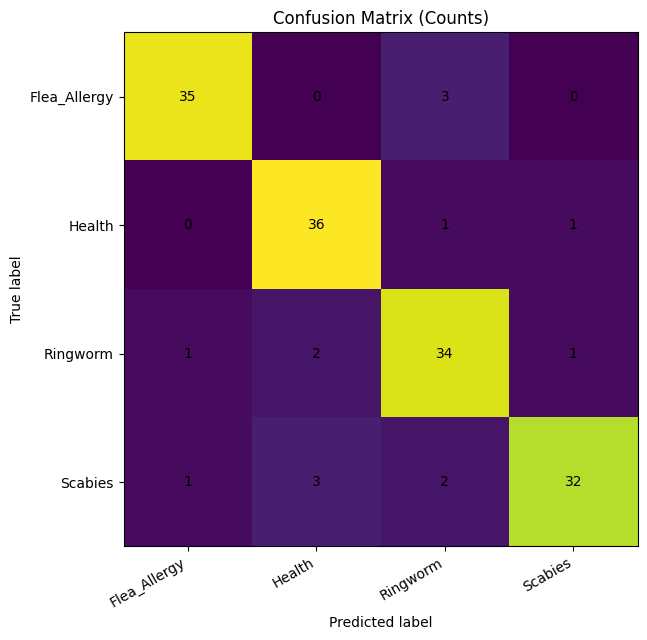

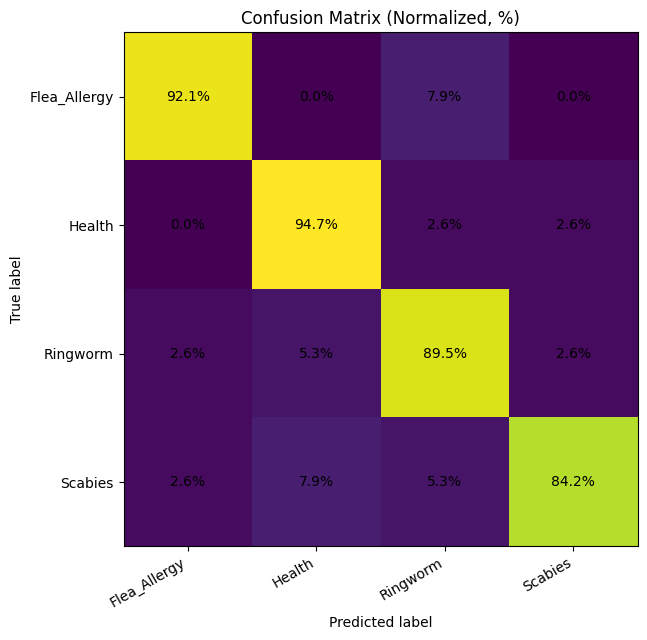

✅ classification_report.csv kaydedildi: /content/results_test/classification_report.csv


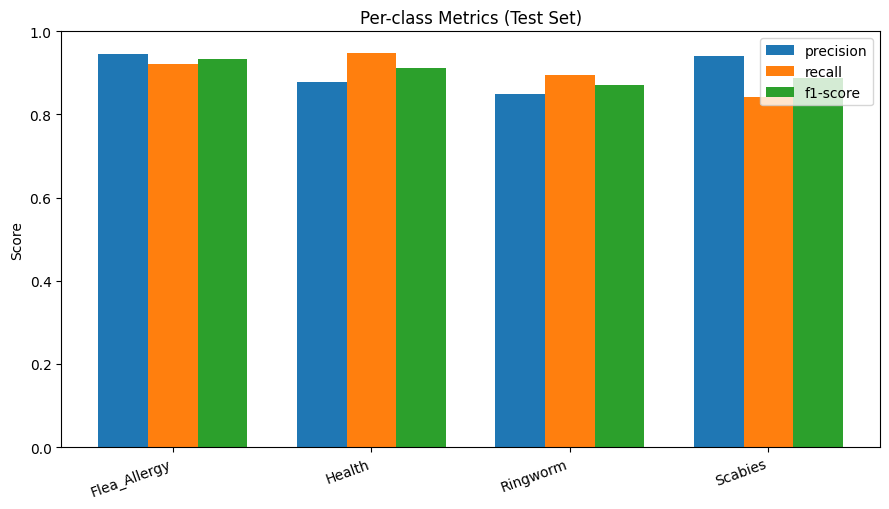

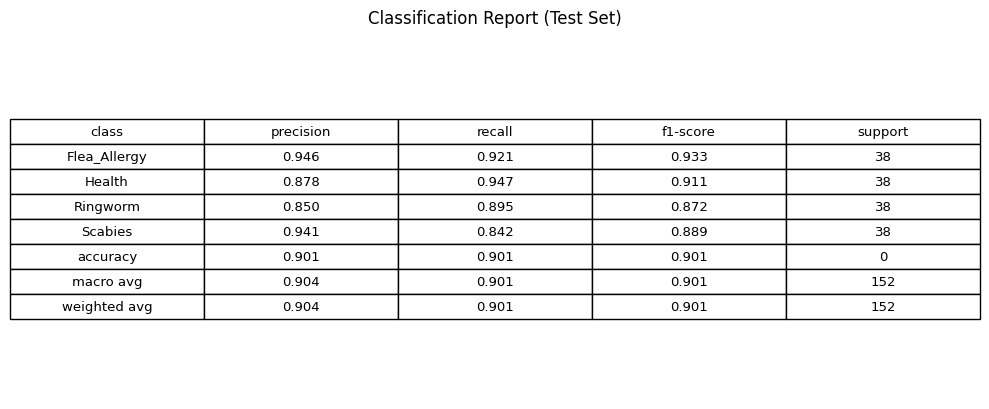

Most confused pair: true='Flea_Allergy' -> pred='Ringworm' (count=3)


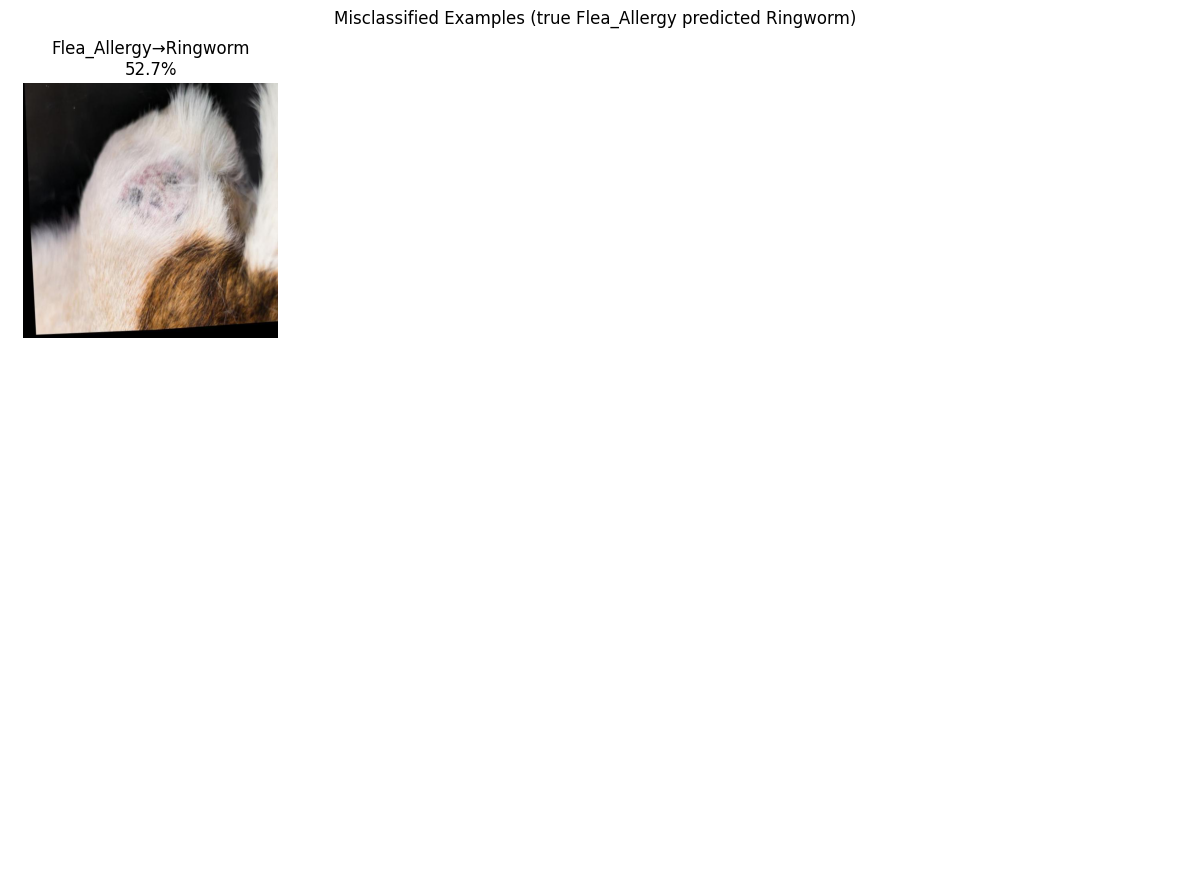


✅ Kaydedilen dosyalar:
 - /content/results_test/confusion_matrix_counts.png
 - /content/results_test/confusion_matrix_normalized.png
 - /content/results_test/metrics_bars.png
 - /content/results_test/classification_report_table.png
 - /content/results_test/classification_report.csv
 - /content/results_test/misclassified_gallery.png
📁 Klasör: /content/results_test


In [ ]:
# ======= FINAL TEST + REPORT EXPORT (ONE CELL) =======
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# ------------------ 0) Ayarlar ------------------
# Test model:
MODEL_PATH = "/content/best_cat_skin_model.keras"

OUT_DIR = Path("/content/results_test")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------ 1) Ön koşullar ------------------
assert "test_ds" in globals(), "test_ds tanımlı değil. Önce dataset loader (Cell 4) çalıştır."
assert "CLASS_NAMES" in globals(), "CLASS_NAMES tanımlı değil. Önce dataset loader (Cell 4) çalıştır."

# TEST_DIR : yanlış sınıflanan galeri için
test_dir = None
if "TEST_DIR" in globals():
    try:
        test_dir = Path(TEST_DIR)
        if not test_dir.exists():
            test_dir = None
    except:
        test_dir = None

# ------------------ 2) Modeli yükle ------------------
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model yüklendi:", MODEL_PATH)

# ------------------ 3) Evaluate (TEST accuracy/loss) ------------------
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"✅ TEST -> acc: {test_acc:.4f} | loss: {test_loss:.4f}")

# ------------------ 4) y_true / y_pred topla ------------------
y_true, y_pred = [], []
for x_batch, y_batch in test_ds:
    pred = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(pred, axis=1))

classes = list(CLASS_NAMES)
n_classes = len(classes)

# ------------------ 5) Confusion Matrix (counts + normalized %) ------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

# Counts CM
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.imshow(cm)
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Counts)")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.tight_layout()
cm_counts_path = OUT_DIR / "confusion_matrix_counts.png"
fig.savefig(cm_counts_path, dpi=220)
plt.show()

# Normalized CM
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.imshow(cm_norm)
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Normalized, %)")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, f"{cm_norm[i, j]*100:.1f}%", ha="center", va="center")
fig.tight_layout()
cm_norm_path = OUT_DIR / "confusion_matrix_normalized.png"
fig.savefig(cm_norm_path, dpi=220)
plt.show()

# ------------------ 6) Classification report (df + table image + bar chart) ------------------
rep = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
df = pd.DataFrame(rep).T
csv_path = OUT_DIR / "classification_report.csv"
df.to_csv(csv_path)
print("✅ classification_report.csv kaydedildi:", csv_path)

# Bar chart
per_class = df.loc[classes, ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(classes))
w = 0.25
ax.bar(x - w, per_class["precision"], w, label="precision")
ax.bar(x,     per_class["recall"],    w, label="recall")
ax.bar(x + w, per_class["f1-score"],  w, label="f1-score")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Per-class Metrics (Test Set)")
ax.legend()
fig.tight_layout()
bars_path = OUT_DIR / "metrics_bars.png"
fig.savefig(bars_path, dpi=220)
plt.show()

# Table image
table_df = df.copy()
for c in ["precision", "recall", "f1-score"]:
    if c in table_df.columns:
        table_df[c] = table_df[c].apply(lambda v: "" if pd.isna(v) else f"{float(v):.3f}")
if "support" in table_df.columns:
    table_df["support"] = table_df["support"].apply(lambda v: "" if pd.isna(v) else str(int(float(v))))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axis("off")
tbl = ax.table(
    cellText=table_df.reset_index().values,
    colLabels=["class"] + list(table_df.columns),
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.35)
ax.set_title("Classification Report (Test Set)", pad=12)
fig.tight_layout()
table_path = OUT_DIR / "classification_report_table.png"
fig.savefig(table_path, dpi=220)
plt.show()

# ------------------ 7) Misclassified gallery (opsiyonel) ------------------
gallery_path = None
if test_dir is not None:
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    true_name, pred_name = classes[i], classes[j]
    print(f"Most confused pair: true='{true_name}' -> pred='{pred_name}' (count={cm_off[i,j]})")

    img_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    true_files = [p for p in (test_dir / true_name).rglob("*") if p.is_file() and p.suffix.lower() in img_ext]

    def load_arr(path):
        img = tf.keras.utils.load_img(path, target_size=(224, 224))
        arr = tf.keras.utils.img_to_array(img)
        arr = np.expand_dims(arr, 0)
        arr = tf.keras.applications.efficientnet.preprocess_input(arr)
        return arr

    N_SCAN = min(200, len(true_files))
    scan_files = true_files[:N_SCAN]

    mis = []
    for p in scan_files:
        arr = load_arr(p)
        prob = model.predict(arr, verbose=0)[0]
        pred_idx = int(np.argmax(prob))
        if pred_idx == j:
            mis.append((p, float(prob[pred_idx])))

    mis = sorted(mis, key=lambda x: x[1], reverse=True)[:12]

    if len(mis) > 0:
        fig, axes = plt.subplots(3, 4, figsize=(12, 9))
        axes = axes.flatten()
        for ax, (p, conf) in zip(axes, mis):
            img = plt.imread(str(p))
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{true_name}→{pred_name}\n{conf*100:.1f}%")
        for k in range(len(mis), len(axes)):
            axes[k].axis("off")

        fig.suptitle(f"Misclassified Examples (true {true_name} predicted {pred_name})", y=0.98)
        fig.tight_layout()
        gallery_path = OUT_DIR / "misclassified_gallery.png"
        fig.savefig(gallery_path, dpi=220)
        plt.show()
    else:
        print("Gallery: taranan örneklerde bu hata bulunamadı.")

# ------------------ 8) Sonuçları yazdır ------------------
print("\n✅ Kaydedilen dosyalar:")
print(" -", cm_counts_path)
print(" -", cm_norm_path)
print(" -", bars_path)
print(" -", table_path)
print(" -", csv_path)
if gallery_path:
    print(" -", gallery_path)
print("📁 Klasör:", OUT_DIR)


✅ Model yüklendi: /content/best_cat_skin_model.keras


Saving Ekran Resmi 2026-12-29 01.33.39.png to Ekran Resmi 2026-12-29 01.33.39 (1).png


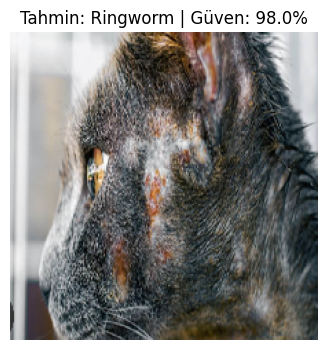

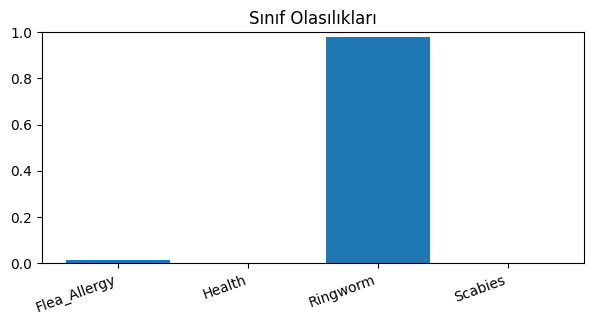

➡️ Ekran Resmi 2026-12-29 01.33.39 (1).png => Ringworm (98.0%)


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from pathlib import Path

MODEL_PATH = "/content/best_cat_skin_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model yüklendi:", MODEL_PATH)

CLASS_NAMES = ["Flea_Allergy", "Health", "Ringworm", "Scabies"]
IMG_SIZE = (224, 224)

def predict_image(img_path: str, warn_threshold=0.60):
    img_path = Path(img_path)

    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = tf.keras.applications.efficientnet.preprocess_input(arr)

    probs = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[idx]
    conf = float(probs[idx])

    # Görsel
    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.axis("off")
    title = f"Tahmin: {pred_name} | Güven: {conf*100:.1f}%"
    if conf < warn_threshold:
        title += "  ⚠️ (Düşük güven)"
    plt.title(title)
    plt.show()

    # Olasılık bar grafiği
    plt.figure(figsize=(7,3))
    x = np.arange(len(CLASS_NAMES))
    plt.bar(x, probs)
    plt.xticks(x, CLASS_NAMES, rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.title("Sınıf Olasılıkları")
    plt.show()

    return pred_name, conf

uploaded = files.upload()
for fn in uploaded.keys():
    pred, conf = predict_image("/content/" + fn)
    print("➡️", fn, "=>", pred, f"({conf*100:.1f}%)")


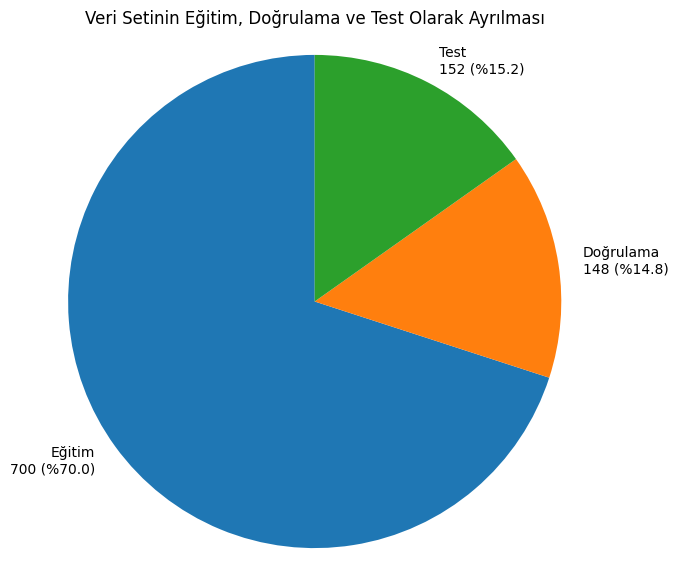

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# === KLASÖR YOLLARINI KONTROL ET ===
TRAIN_DIR = Path("/content/cat_skin_split/train")
VAL_DIR   = Path("/content/cat_skin_split/val")
TEST_DIR  = Path("/content/cat_skin_split/test")

def count_images(root):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for f in root.rglob("*") if f.suffix.lower() in exts)

train_count = count_images(TRAIN_DIR)
val_count   = count_images(VAL_DIR)
test_count  = count_images(TEST_DIR)

total = train_count + val_count + test_count

sizes = [train_count, val_count, test_count]
labels = [
    f"Eğitim\n{train_count} (%{train_count/total*100:.1f})",
    f"Doğrulama\n{val_count} (%{val_count/total*100:.1f})",
    f"Test\n{test_count} (%{test_count/total*100:.1f})"
]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, startangle=90)
plt.axis("equal")
plt.title("Veri Setinin Eğitim, Doğrulama ve Test Olarak Ayrılması")

plt.savefig("dataset_split_pie.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path

# ================== AYARLAR ==================
MODEL_PATH = "/content/best_cat_skin_model.keras"
CLASS_NAMES = ["Flea_Allergy", "Health", "Ringworm", "Scabies"]
OUT_DIR = Path("/content/results_metric_tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ================== MODEL YÜKLE ==================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model yüklendi:", MODEL_PATH)

# ================== TEST TAHMİNLERİ ==================
y_true, y_pred = [], []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# ================== 1) ACCURACY TABLOSU ==================
accuracy = accuracy_score(y_true, y_pred)

accuracy_df = pd.DataFrame({
    "Metrik": ["Accuracy (Doğruluk)"],
    "Açıklama": ["Genel sınıflandırma başarısı"],
    "Değer": [round(accuracy, 4)]
})

# ================== 2) PRECISION / RECALL / F1 TABLOSU ==================
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

prf_df = (
    pd.DataFrame(report)
    .T
    .loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={"index": "Sınıf",
                     "precision": "Precision (Kesinlik)",
                     "recall": "Recall (Duyarlılık)",
                     "f1-score": "F1-Skoru",
                     "support": "Görüntü Sayısı"})
)

prf_df[["Precision (Kesinlik)", "Recall (Duyarlılık)", "F1-Skoru"]] = \
    prf_df[["Precision (Kesinlik)", "Recall (Duyarlılık)", "F1-Skoru"]].round(3)

# ================== 3) CONFUSION MATRIX TABLOSU ==================
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Gerçek_{c}" for c in CLASS_NAMES],
    columns=[f"Tahmin_{c}" for c in CLASS_NAMES]
)

# ================== KAYDET ==================
accuracy_df.to_csv(OUT_DIR / "accuracy_table.csv", index=False)
prf_df.to_csv(OUT_DIR / "precision_recall_f1_table.csv", index=False)
cm_df.to_csv(OUT_DIR / "confusion_matrix_table.csv")

# ================== GÖSTER ==================
print("\n📌 Accuracy Tablosu")
display(accuracy_df)

print("\n📌 Precision / Recall / F1 Tablosu")
display(prf_df)

print("\n📌 Confusion Matrix Tablosu")
display(cm_df)

print("\n✅ Kaydedilen dosyalar:")
print(" - accuracy_table.csv")
print(" - precision_recall_f1_table.csv")
print(" - confusion_matrix_table.csv")
print("📁 Klasör:", OUT_DIR)


✅ Model yüklendi: /content/best_cat_skin_model.keras

📌 Accuracy Tablosu


,Metrik,Açıklama,Değer
0,Accuracy (Doğruluk),Genel sınıflandırma başarısı,0.9013



📌 Precision / Recall / F1 Tablosu


,Sınıf,Precision (Kesinlik),Recall (Duyarlılık),F1-Skoru,Görüntü Sayısı
0,Flea_Allergy,0.946,0.921,0.933,38.0
1,Health,0.878,0.947,0.911,38.0
2,Ringworm,0.850,0.895,0.872,38.0
3,Scabies,0.941,0.842,0.889,38.0



📌 Confusion Matrix Tablosu


,Tahmin_Flea_Allergy,Tahmin_Health,Tahmin_Ringworm,Tahmin_Scabies
Gerçek_Flea_Allergy,35,0,3,0
Gerçek_Health,0,36,1,1
Gerçek_Ringworm,1,2,34,1
Gerçek_Scabies,1,3,2,32



✅ Kaydedilen dosyalar:
 - accuracy_table.csv
 - precision_recall_f1_table.csv
 - confusion_matrix_table.csv
📁 Klasör: /content/results_metric_tables


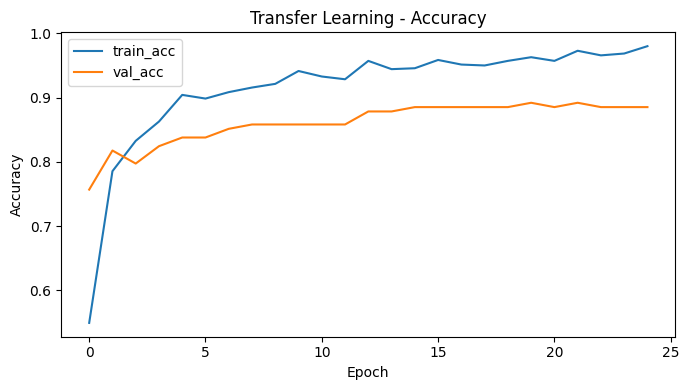

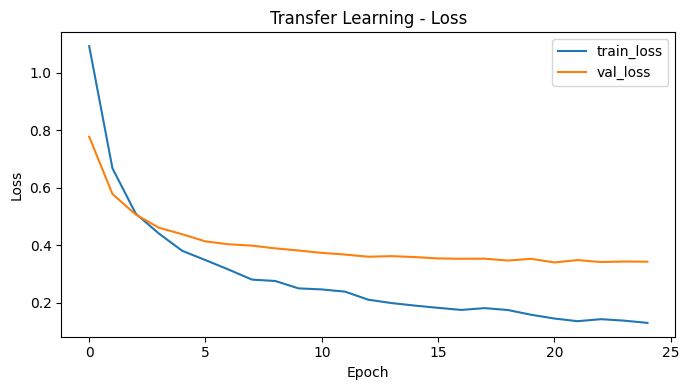

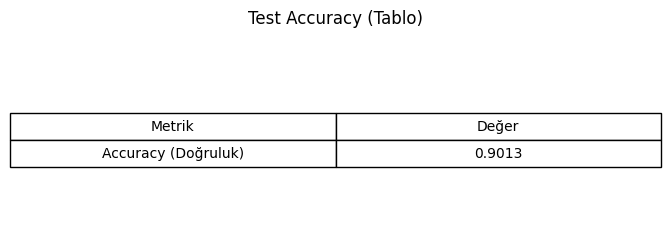

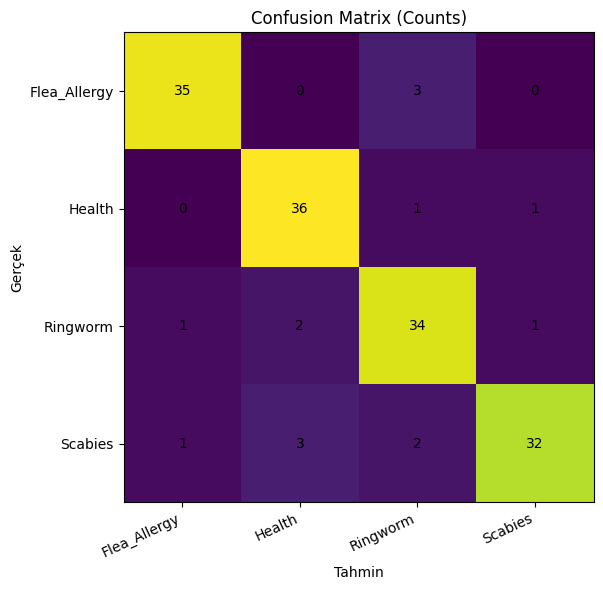

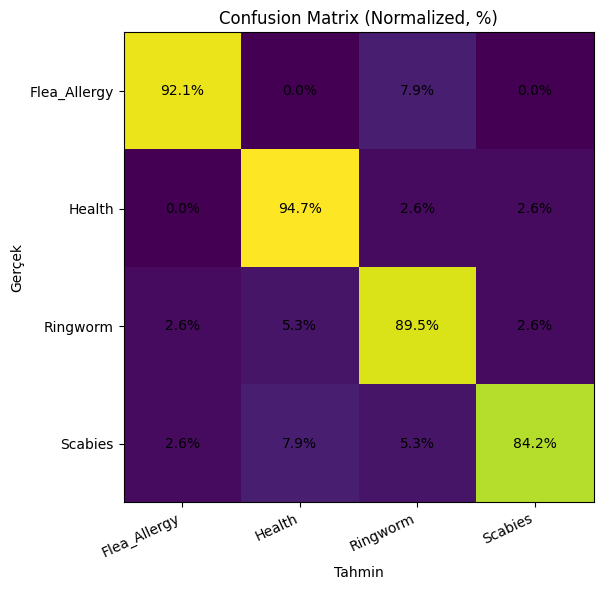

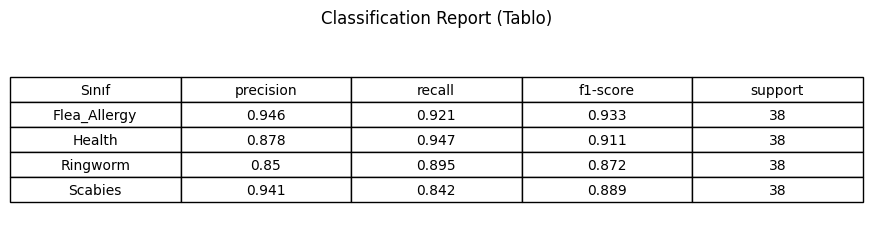

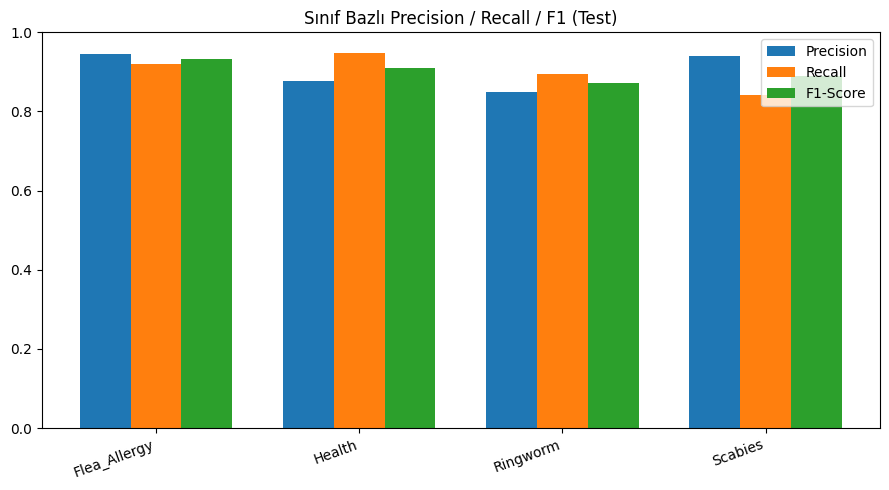

✅ Hepsi ekrana basıldı. SS alabilirsin.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ====== Gerekirse model yükle (model zaten varsa elleme) ======
MODEL_PATH = "/content/best_cat_skin_model.keras"
if "model" not in globals():
    model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Model yüklendi:", MODEL_PATH)

# ====== Kontroller ======
assert "test_ds" in globals(), "test_ds yok. Önce dataset loader cell'ini çalıştır."
assert "CLASS_NAMES" in globals(), "CLASS_NAMES yok. Önce sınıf isimlerini oluştur."

# ====== Yardımcı: tabloyu görsel olarak çiz (SS için) ======
def show_table(df, title, font_size=10, scale=(1.2, 1.6)):
    fig, ax = plt.subplots(figsize=(max(7, df.shape[1]*2.0), max(2.6, df.shape[0]*0.6)))
    ax.axis("off")
    ax.set_title(title, pad=12)
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)
    tbl.scale(scale[0], scale[1])
    plt.show()

# =========================
# 1) Accuracy / Loss Eğrileri (history varsa)
# =========================
def plot_history(h, title_prefix="Training"):
    hist = h.history

    plt.figure(figsize=(7,4))
    if "accuracy" in hist: plt.plot(hist["accuracy"], label="train_acc")
    if "val_accuracy" in hist: plt.plot(hist["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    if "loss" in hist: plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist: plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.tight_layout()
    plt.show()

if "history" in globals():
    plot_history(history, "Transfer Learning")
elif "history_ft" in globals():
    plot_history(history_ft, "Fine Tuning")
elif "history_focal" in globals():
    plot_history(history_focal, "Focal Fine Tuning")
else:
    print("⚠️ history bulunamadı (eğitim eğrisi çizilmedi). Eğitimi çalıştırdıysan history değişkenini kontrol et.")

# =========================
# 2) Test tahminleri (y_true / y_pred)
# =========================
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    y_true.extend(np.argmax(yb.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

# =========================
# 3) Accuracy Tablo (SS için)
# =========================
acc = accuracy_score(y_true, y_pred)
df_acc = pd.DataFrame({"Metrik": ["Accuracy (Doğruluk)"], "Değer": [f"{acc:.4f}"]})
show_table(df_acc, "Test Accuracy (Tablo)")

# =========================
# 4) Confusion Matrix (adet + normalize %)
# =========================
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

# Adet
fig, ax = plt.subplots(figsize=(7,6))
ax.imshow(cm)
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
ax.set_title("Confusion Matrix (Counts)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

# Normalize %
fig, ax = plt.subplots(figsize=(7,6))
ax.imshow(cm_norm)
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
ax.set_title("Confusion Matrix (Normalized, %)")
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]*100:.1f}%", ha="center", va="center")
plt.tight_layout()
plt.show()

# =========================
# 5) Classification Report Tablo (SS için)
# =========================
rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
df_rep = pd.DataFrame(rep).T.loc[CLASS_NAMES, ["precision","recall","f1-score","support"]].copy()
df_rep[["precision","recall","f1-score"]] = df_rep[["precision","recall","f1-score"]].round(3)
df_rep["support"] = df_rep["support"].astype(int)
df_rep.insert(0, "Sınıf", df_rep.index)

show_table(df_rep.reset_index(drop=True), "Classification Report (Tablo)", font_size=10, scale=(1.1, 1.5))

# =========================
# 6) Precision / Recall / F1 bar
# =========================
plt.figure(figsize=(9,5))
x = np.arange(len(CLASS_NAMES)); w = 0.25
plt.bar(x-w, df_rep["precision"], w, label="Precision")
plt.bar(x,   df_rep["recall"],    w, label="Recall")
plt.bar(x+w, df_rep["f1-score"],  w, label="F1-Score")
plt.xticks(x, CLASS_NAMES, rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Sınıf Bazlı Precision / Recall / F1 (Test)")
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Hepsi ekrana basıldı. SS alabilirsin.")
